# Gram Newton Schulz
Let $G \in \R^{m \times n}$ where $m \leq n = \alpha m$. We want to compute
$$\mathrm{polar}(G) = (GG^\top)^{-1/2} G$$

The standard Newton-Schulz-like iteration is $$X_0 = G, \quad X_t = p_t(X_{t-1})$$ where $p_t$ is a polynomial like $p_t(M) = \tfrac32 M - \tfrac12 MM^\top M$. Here, $(p_1, p_2, \ldots)$ is a sequence of odd polynomials satisfying $$\lim_{T \to \infty} (p_T \circ \cdots \circ p_1)(x) \to 1 \quad \forall x \in (0, 1]$$
This ensures that Newton Schulz converges for all $G$ such that $\|G\|_2 \leq 1$.
If run for $T$ iterations, the runtime of Newton Schulz is $\approx 2\alpha T m^3$.

The alternative version aims to do as much computation as possible with small $m \times m$ matrices. We call this method "Gram Newton Schulz". The outline of the method is as follows:
1. Form the Gram matrix $GG^\top$
2. Compute the approximation $Q_T \approx (GG^\top)^{-1/2}$ using an iterative polynomial method
3. Form $Q_T G$

Steps 1 and 3 each require multiplying $m \times n$ matrices. However, step 2 does not. Therefore, the runtime of Gram Newton Schulz is just $(3T + 2\alpha)m^3$. Figuring $T=5, \alpha=4$, this version is 43\% faster. (When we instead use degree-5 polynomials $p_t(x) = ax + bx^3 + cx^5$, standard Newton Schulz costs $(2\alpha + 1)Tm^3$ while Gram Newton Schulz costs $(4T + 2\alpha)m^3$, 38\% faster.)

## Newton Schulz as an inverse square root method
It remains to construct an approximation to $(GG^\top)^{-1/2}$. As wtih Newton Schulz, we restrict ourselves to methods based on matrix polynomials.
As it turns out, such a method can be derived from any sequence of odd polynomials $(p_1, p_2, \ldots)$ that satisfies the convergence criterion for Newton Schulz given above. If we use this 
If we use this method in step 2, then the overall Gram Newton Schulz procedure will be exactly equivalent to standard Newton Schulz in exact arithmetic.

We begin with the scalar analogue of the method.
Let $x_0 \in (0, 1]$ and $x_t = p_t(x_{t-1})$, as in standard Newton Schulz.
Since $p_t$ is odd, it can be written as $p_t(x) = x h_t(x^2)$, where $h_t$ is a polynomial like $h_t(x) = \tfrac32 - \tfrac12 x$.
Define 
Define $r_t := x_t^2$ and $z_t := h_t(r_{t-1})$. Then
$$x_{t} = p_t(x_{t-1}) = x_{t-1} h_t(x_{t-1}^2) = x_{t-1} h_t(r_{t-1}) = x_{t-1} z_t$$
Squaring both sides yields
$$r_t = r_{t-1} z_t^2$$
If we define $q_t := x_t / x_0$, then we can also derive
$$q_t = q_{t-1} z_t$$
Finally, $1 = \lim_{T \to \infty} x_T = \lim_{T \to \infty} q_T x_0 = \lim_{T \to \infty} q_T \sqrt{r_0} \implies q_T \to 1/\sqrt{r_0}$. Thus, the following iterative method computes the inverse square root of $r_0$:
- $z_t = h_t(r_{t-1})$
- $r_t = r_{t-1} z_t^2$
- $q_t = q_{t-1} z_t$&emsp;(where we initialize $q_0 = 1$).

Furthermore, if we initialize this method with $r_0 = x_0^2$, then our analysis shows that $x_T = q_T x_0$ is precisely the output of standard Newton Schulz. Thus, we have computed $x_T$ from $x_0$ without ever constructing the intermediate values $x_1, \ldots X_{T-1}$.

To obtain Gram Newton Schulz, we simply lift the above procedure to matrices:

Initialize $R_0 = GG^\top$ and $Q_0 = I_m$.

Repeat for $t=1, \ldots,\,T$:
- $Z_t = h_t(R_{t-1})$
- $R_t = Z_t^\top R_{t-1} Z_t$
- $Q_t = Q_{t-1}Z_t$

Output $X_T = Q_T G$.

The trouble comes when $G$ is numerically low rank, so that $GG^\top$ does not have an inverse square root. When working in low precision, $GG^\top$ may even have negative eigenvalues. In this case, the alternative method suffers from catastrophic blowups. By tracking how these negative eigenvalues evolve, we can intervene to prevent this trouble while retaining some of the speedup.

## Tracking the Spectra in Gram Newton Schulz 

We will now demonstrate Gram Newton Schulz on a simple synthetic example of a $128 \times 512$ matrix with an exponentially decaying spectrum. We will use the degree-5 Newton Schulz polynomial $p_t(x) = \tfrac{15}8 x - \tfrac{10}8 x^3 + \tfrac38 x^5$.

By construction, $Z_t, R_t$, and $Q_t$ are symmetric.
Because the only operations we perform are matrix polynomials, the eigenvectors of all of these matrices are identical, and they match the left singular vectors of $X_t$.
We can therefore plot the eigenvalues of $R_t$ and $Q_t$ against the corresponding singular values of $X_0$ to trace how each evolves according to the polynomial iterations.
Even though our method does not need to compute the intermediate matrices $X_1, \ldots X_{T-1}$, we do so here for demonstration.

In [13]:
import matplotlib.pyplot as plt
from matplotlib.scale import AsinhScale
import numpy as np
import pandas as pd
import torch

%load_ext autoreload
%autoreload 2
from appF_diagnostic import *

DEVICE = 'cuda:1'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
n = 128
aspect_ratio = 4
spectrum = torch.logspace(-0.01, -8, steps=n, dtype=torch.float64, device=DEVICE)
G = spectrum2matrix(spectrum, aspect_ratio)

_, f64_diagnostics = PolarExpressDiagnostic(
    coeffs_name="ns5",
    steps=10,
)(G)

HTML(spectrum_evolution_plot(f64_diagnostics).to_jshtml())

Initially, we have $r_0 = x_0^2$, and $q_0 = 1$. As training procedes, $q_t$ approaches $1/\sqrt{r_0} = 1/x_0$, and so $x_t = q_t x_0$ approaches $1$. Since $r_t = x_t^2$, it too approaches 1. (We can also see the gap between $r_t$ and $1$ as a measure of the error in the approximation $q_t \approx 1/\sqrt{r_0}$, since $r_t = q_t^2 r_0$.) Note that if $x_0$ is close to 1, the method converges quickly, while if $x_0$ is close to zero, it converges slowly. After 10 iterations, the spectrum of $X_t$ is visually indistinguishable from $1$.

So far, this is all expected. As we showed above, Gram Newton Schulz is exactly equivalent to Newton Schulz in exact arithmetic.

## Trouble in Low Precision
Unfortunately, in floating point arithemtic, Gram Newton Schulz is not equivalent to the standard version; it is less numerically stable. Let's see what happens when we repeat the previous experiment in `bfloat16` arithmetic.

In [10]:
_, f16_diagnostics = PolarExpressDiagnostic(
    coeffs_name="ns5",
    steps=10,
    ambient_dtype=torch.bfloat16
)(G)

HTML(spectrum_evolution_plot(f16_diagnostics).to_jshtml())

The first few iterations proceed as before. However, by step 7, we see unexpected behavior in the spectrum of $X$. The singular values that began near $0$ suddenly jump up above 1, instead of converging to 1 from below. By step 8, the algorithm is returning complete junk, and by step 10 the singular values are literally off the charts. What happened?

If you look closely, you can see that the trouble begins in the matrix $R$. By construction, $r_t = x_t^2 \geq 0$, and $R_t$ is a positive semidefinite matrix. However, our plots show that $R$ has negative eigenvalues! Let's transform the y-axis to emphasize values close to zero and replot this. Now we see that from the very beginning, $R$ has tiny negative eigenvalues 

In [ ]:
HTML(spectrum_evolution_plot(f16_diagnostics, yscale='asinh', linear_width=1e-4).to_jshtml())

In [17]:
n = 512
aspect_ratio = 4
spectrum = torch.logspace(-0.01, -8, steps=n, dtype=torch.float64, device=DEVICE)
assert torch.all(spectrum[:-1] >= spectrum[1:]), "spectrum must be decreasing"
# G = torch.diag(spectrum)
G = spectrum2matrix(spectrum, aspect_ratio)

PE = PolarExpressDiagnostic(
    coeffs_name="polar5",
    steps=5,
    restarts=[2],  # list(range(5)),
    force_symmetry=True,
    ambient_dtype=torch.float64,
    xxt_posthoc_dtype=torch.bfloat16,
    # qx_dtype=torch.bfloat16,
    do_diagnostics=True,
)
out, diagnostics = PE(G)
df = pd.DataFrame(diagnostics)
# since Z and Q are decreasing functions of the corresponding singular value of X_0, flip them for plotting purposes
df['Z_singvals'] = df['Z_singvals'].apply(np.flip)
df['Q_singvals'] = df['Q_singvals'].apply(np.flip)

Text(0.5, 0, 'Iteration')

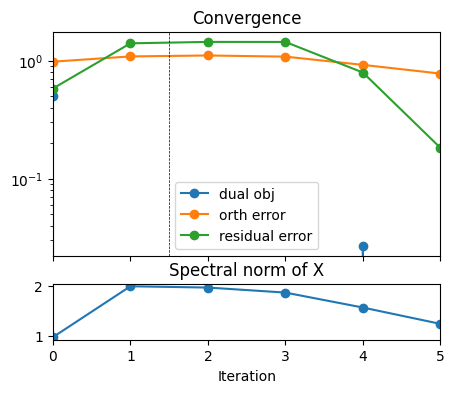

In [18]:
fig, ax = plt.subplots(2, figsize=(5, 4), height_ratios=(4, 1), sharex=True)

ax[0].plot(df['dual_obj'], marker='o', label='dual obj')
ax[0].plot(df['orth_error'], marker='o', label='orth error')
ax[0].plot(df['residual_error'], marker='o', label='residual error')

for restart in PE.restarts:
    ax[0].axvline(x=restart - 0.5, color='black', linestyle='dashed', linewidth=0.5)

ax[0].set_title("Convergence")
ax[0].set_yscale("log")
ax[0].set_xlim(0, len(df) - 1)
ax[0].legend();

ax[1].plot(df['X_max_singval'], marker='o')

ax[1].set_title("Spectral norm of X")
ax[1].set_xlabel("Iteration")

In [7]:
df.loc[0, ['R_min_singval_from_starting_vecs', 'R_min_singval']]

R_min_singval_from_starting_vecs   -0.000033
R_min_singval                      -0.000365
Name: 0, dtype: object

In [8]:
import numpy as np
np.allclose(df.loc[0, 'X_singvals_from_starting_vecs'], df.loc[0, 'X_singvals'])

True

In [16]:
HTML(spectrum_evolution_plot(df).to_jshtml())

In [ ]:
rs, qs = PE.track_eigvals(torch.linspace(-1e-3, 1, steps=100, device=DEVICE, dtype=torch.float64))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

def update(frame):
    for ax, col, title in zip(axes, (rs, qs), ("R eigvals", "Q eigvals")):
        vals = col[frame].cpu().numpy()
        ax.plot(rs[0].cpu().numpy(), vals, label=f'step {frame}')
        ax.set_title(f'{title} (steps 0 – {frame})')
        ax.set_xlabel('R_0 eigenvalues')
        ax.set_xscale('symlog')
        ax.legend(loc='upper right', fontsize='small')

ani = FuncAnimation(fig, update, frames=len(rs), init_func=lambda: [], interval=500, repeat=False)
plt.close(fig)
HTML(ani.to_jshtml())